In [1]:
!pip install xgboost

In [2]:
import numpy
import pandas
import sklearn
import matplotlib
import pickle
import seaborn
import flask
import joblib
import xgboost

print("All libraries installed successfully")

All libraries installed successfully


In [3]:
import pandas as pd
df = pd.read_excel("../Dataset/flood dataset.xlsx")
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
dataset = pd.read_excel("../Dataset/flood dataset.xlsx")
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


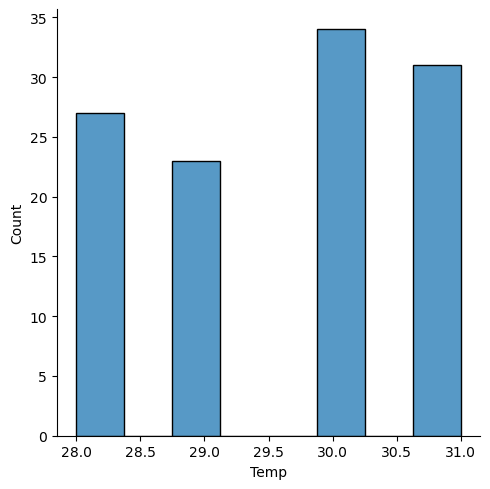

In [6]:
sns.displot(dataset['Temp'])
plt.show()

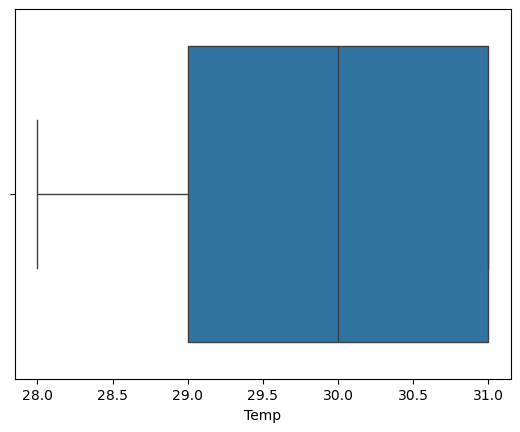

In [7]:
sns.boxplot(x=dataset['Temp'])
plt.show()

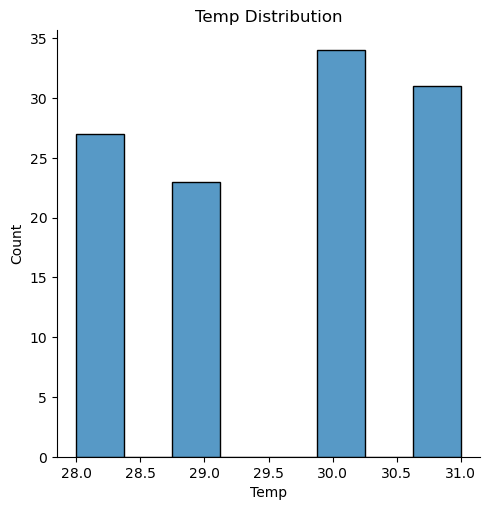

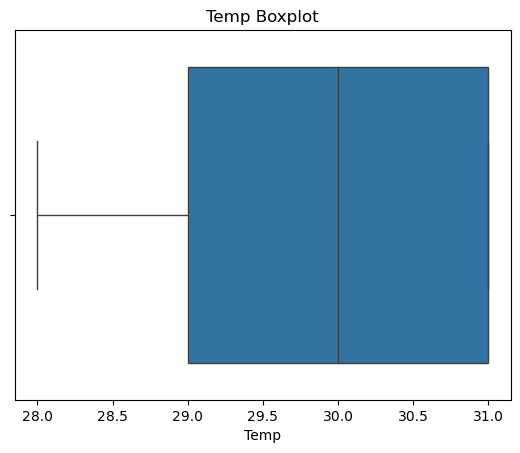

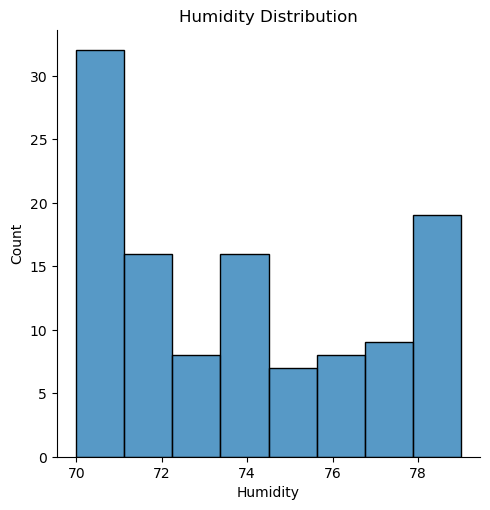

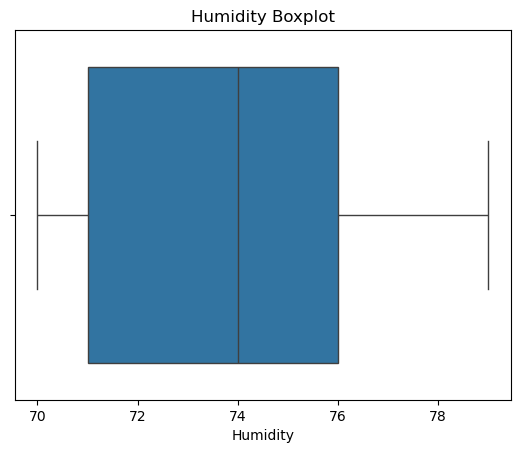

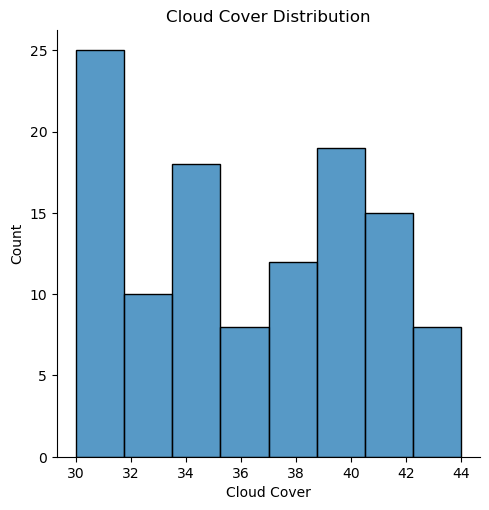

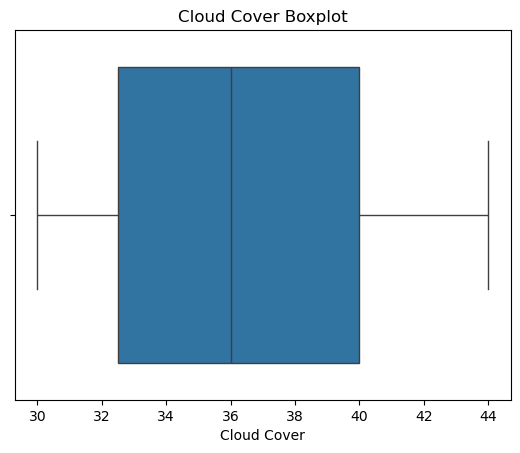

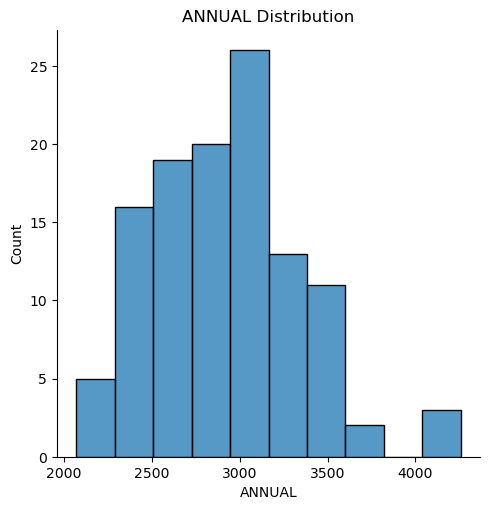

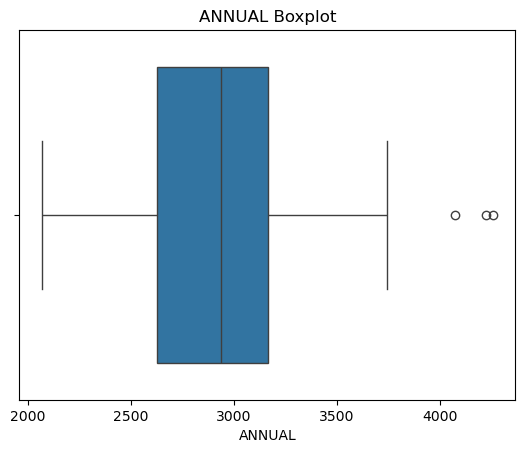

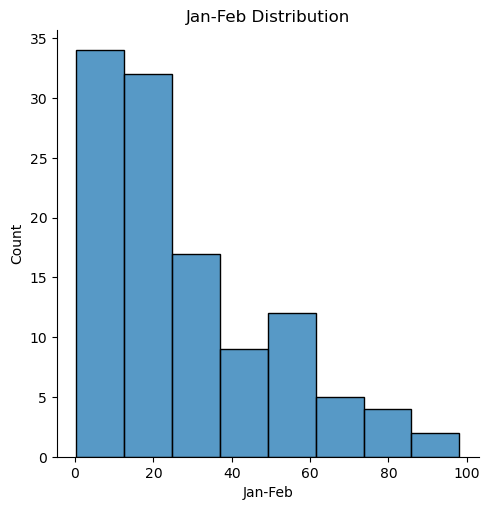

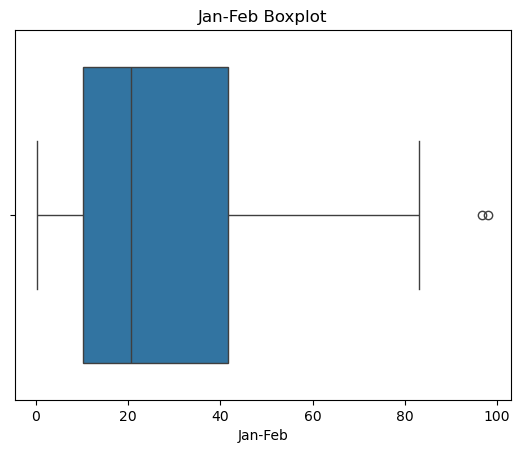

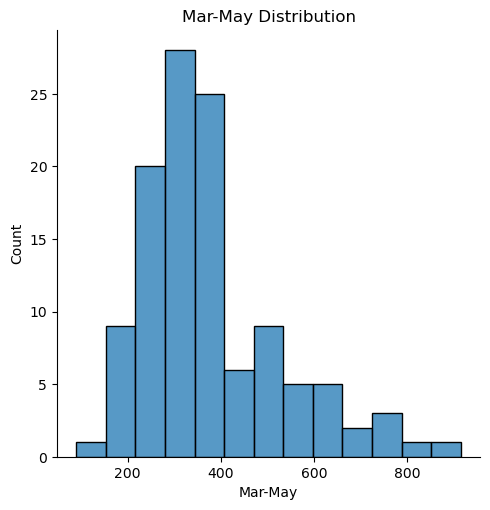

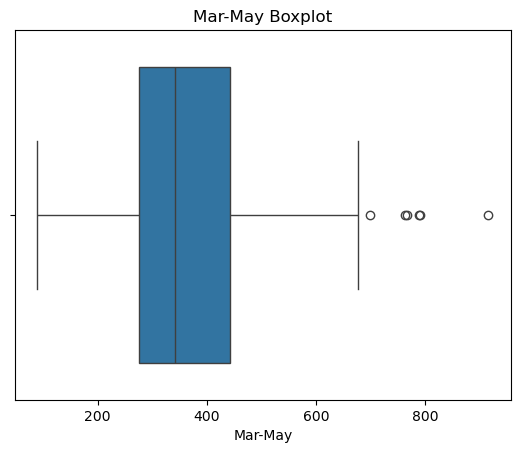

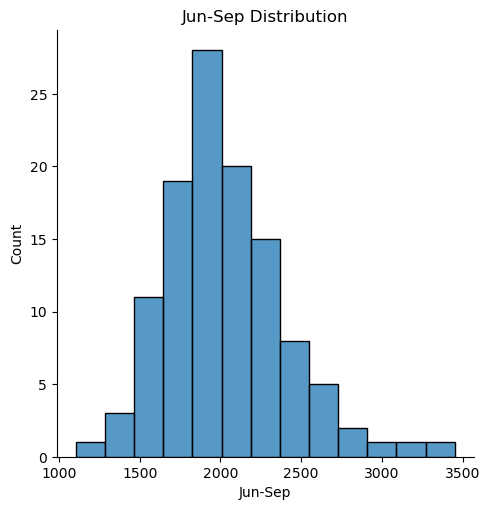

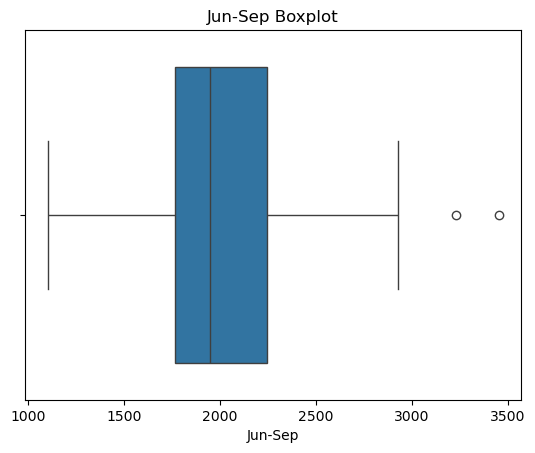

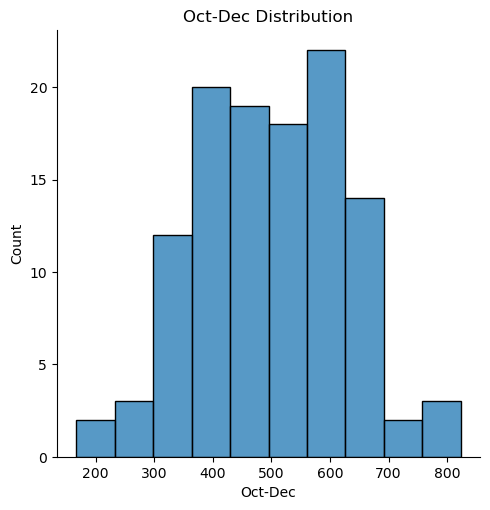

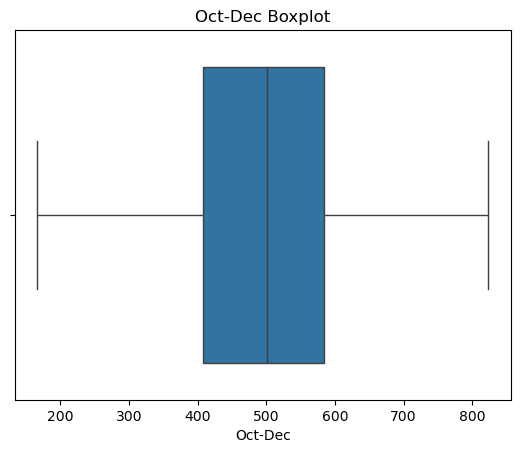

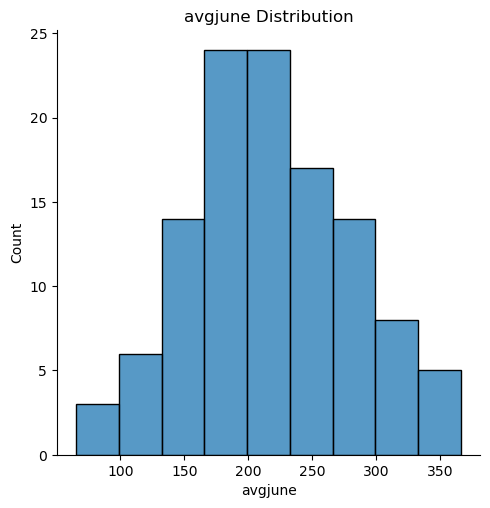

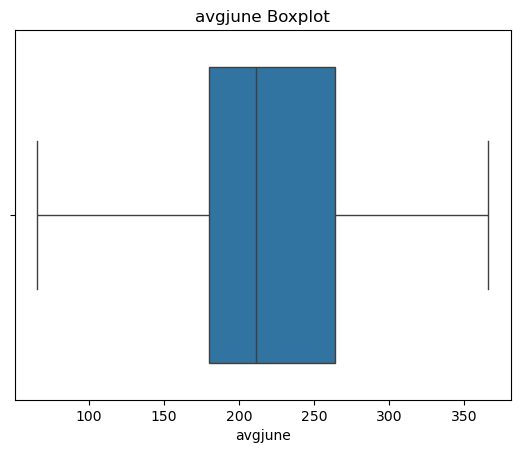

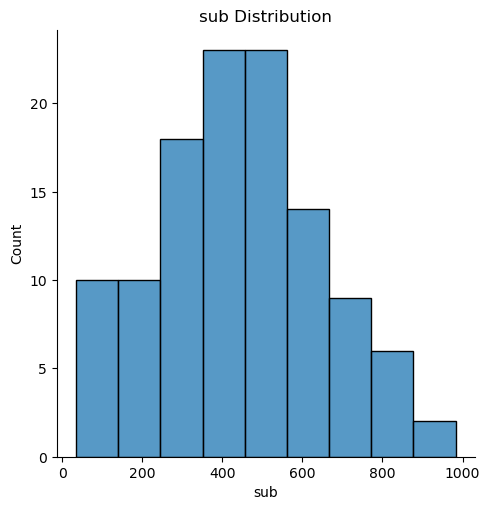

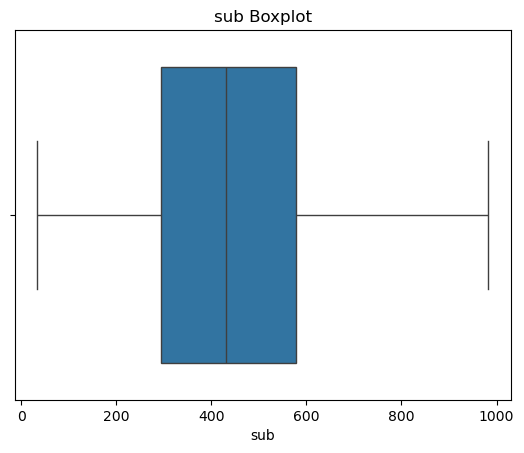

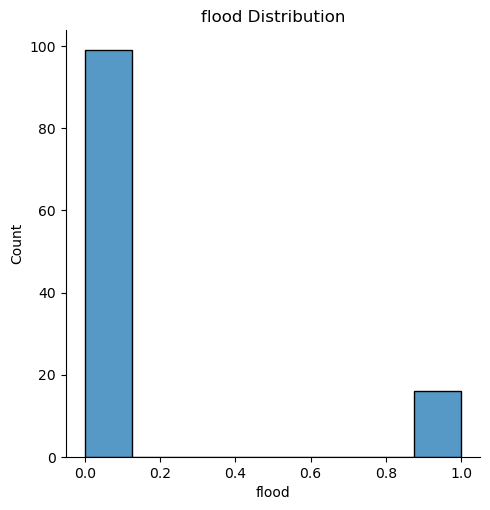

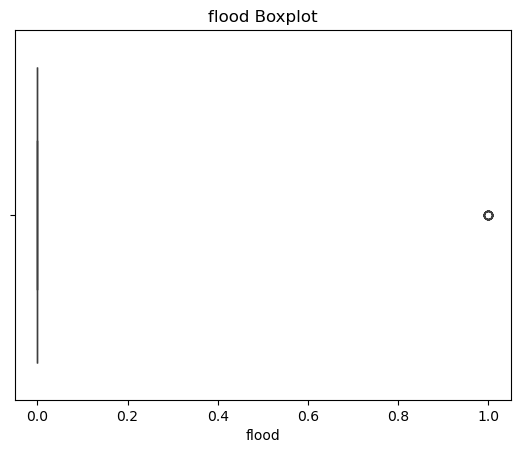

In [8]:
for col in dataset.columns:
    sns.displot(dataset[col])
    plt.title(col + " Distribution")
    plt.show()

    sns.boxplot(x=dataset[col])
    plt.title(col + " Boxplot")
    plt.show()

In [9]:
corr = dataset.corr()
corr

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
Temp,1.000000,-0.012727,-0.046568,-0.063014,-0.080076,0.099519,-0.081965,-0.063034,-0.019751,-0.088331,-0.080946
Humidity,-0.012727,1.000000,0.085824,-0.054767,-0.185965,-0.101232,-0.029583,0.059739,0.017656,0.029981,0.020250
Cloud Cover,-0.046568,0.085824,1.000000,0.051166,0.004376,0.096645,0.010833,0.020966,-0.089843,-0.106455,0.089801
ANNUAL,-0.063014,-0.054767,0.051166,1.000000,0.033639,0.387790,0.861190,0.232069,0.474644,0.220009,0.626874
Jan-Feb,-0.080076,-0.185965,0.004376,0.033639,1.000000,0.066479,0.001178,-0.143670,0.164691,0.201266,-0.084446
Mar-May,0.099519,-0.101232,0.096645,0.387790,0.066479,1.000000,-0.029007,0.171805,0.019183,-0.475750,-0.017598
Jun-Sep,-0.081965,-0.029583,0.010833,0.861190,0.001178,-0.029007,1.000000,-0.141467,0.511113,0.431997,0.705202
Oct-Dec,-0.063034,0.059739,0.020966,0.232069,-0.143670,0.171805,-0.141467,1.000000,-0.028055,-0.050862,-0.024852
avgjune,-0.019751,0.017656,-0.089843,0.474644,0.164691,0.019183,0.511113,-0.028055,1.000000,0.780445,0.379778
sub,-0.088331,0.029981,-0.106455,0.220009,0.201266,-0.475750,0.431997,-0.050862,0.780445,1.000000,0.349828


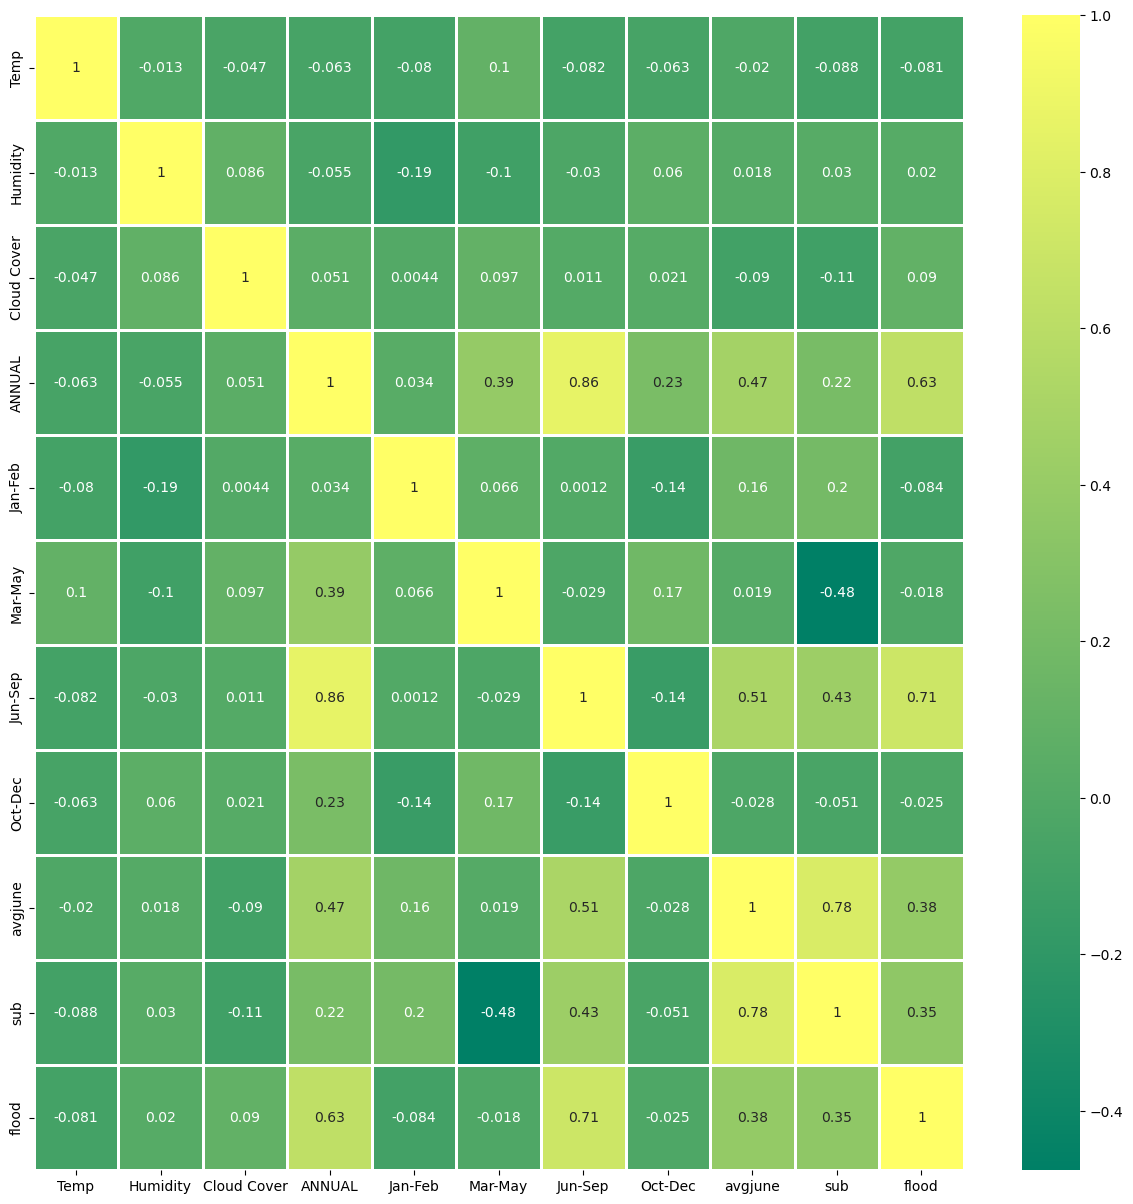

In [10]:
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap="summer", linewidths=1)
plt.show()

In [14]:
corr["flood"].sort_values()

Jan-Feb       -0.084446
Temp          -0.080946
Oct-Dec       -0.024852
Mar-May       -0.017598
Humidity       0.020250
Cloud Cover    0.089801
sub            0.349828
avgjune        0.379778
ANNUAL         0.626874
Jun-Sep        0.705202
flood          1.000000
Name: flood, dtype: float64

In [15]:
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [13]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Temp,115.0,29.600000,1.122341,28.0,29.000000,30.000000,31.000000,31.000000
Humidity,115.0,73.852174,2.947623,70.0,71.000000,74.000000,76.000000,79.000000
Cloud Cover,115.0,36.286957,4.330158,30.0,32.500000,36.000000,40.000000,44.000000
ANNUAL,115.0,2925.487826,422.112193,2068.8,2627.900000,2937.500000,3164.100000,4257.800000
Jan-Feb,115.0,27.739130,22.361032,0.3,10.250000,20.500000,41.600000,98.100000
Mar-May,115.0,377.253913,151.091850,89.9,276.750000,342.000000,442.300000,915.200000
Jun-Sep,115.0,2022.840870,386.254397,1104.3,1768.850000,1948.700000,2242.900000,3451.300000
Oct-Dec,115.0,497.636522,129.860643,166.6,407.450000,501.500000,584.550000,823.300000
avgjune,115.0,218.100870,62.547597,65.6,179.666667,211.033333,263.833333,366.066667
sub,115.0,439.801739,210.438813,34.2,295.000000,430.600000,577.650000,982.700000


In [16]:
dataset.isnull().any()

Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

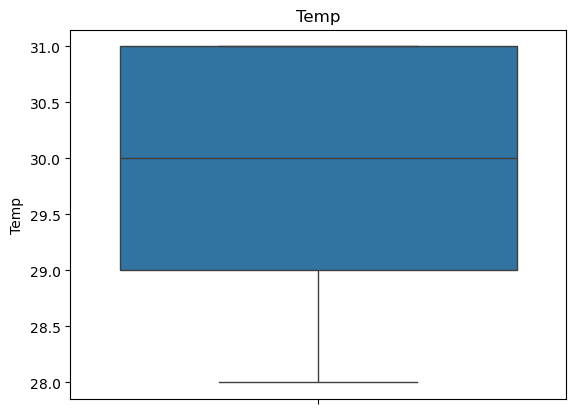

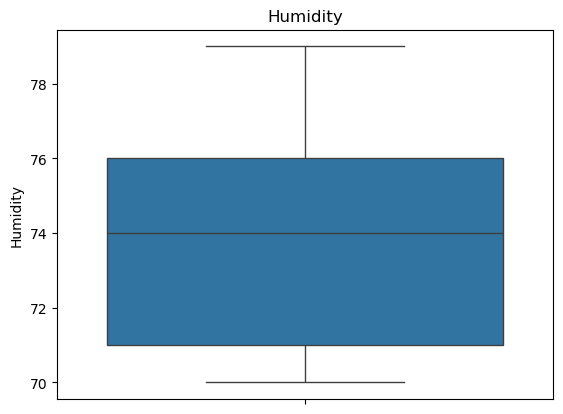

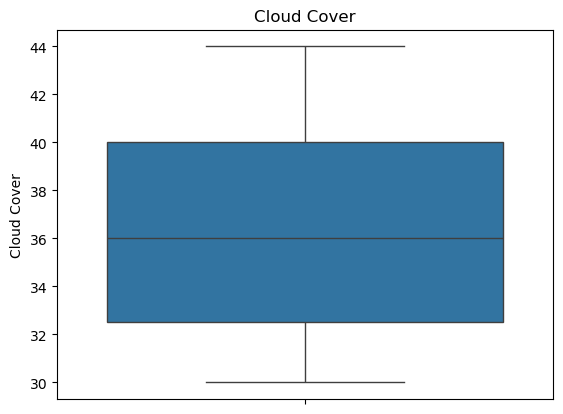

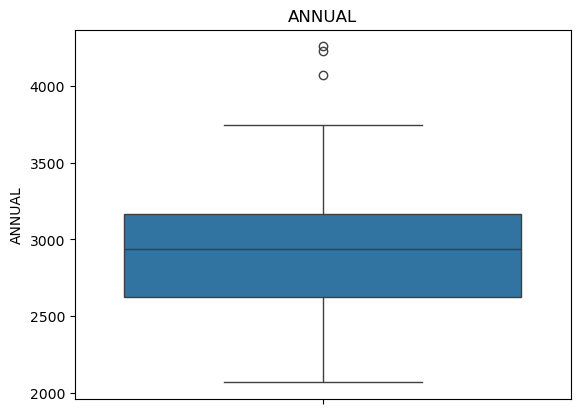

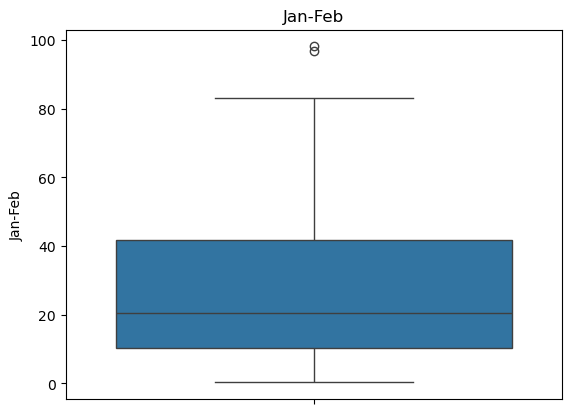

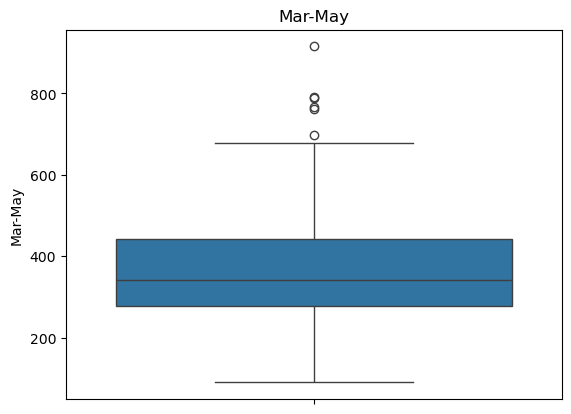

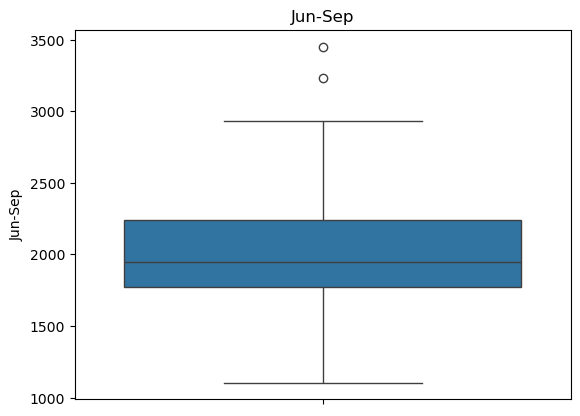

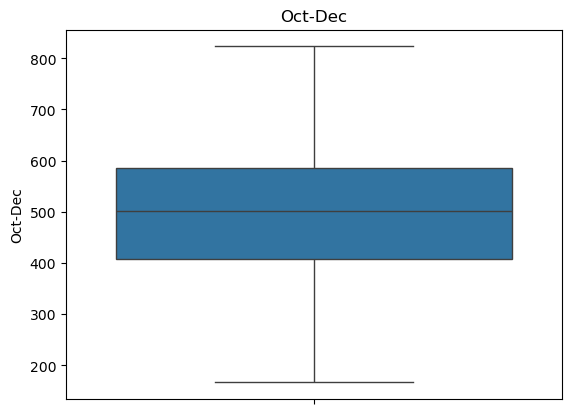

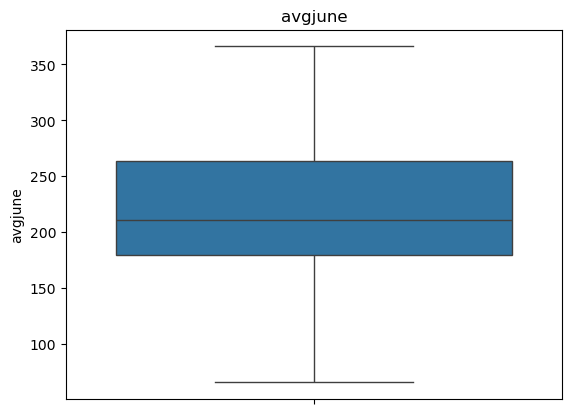

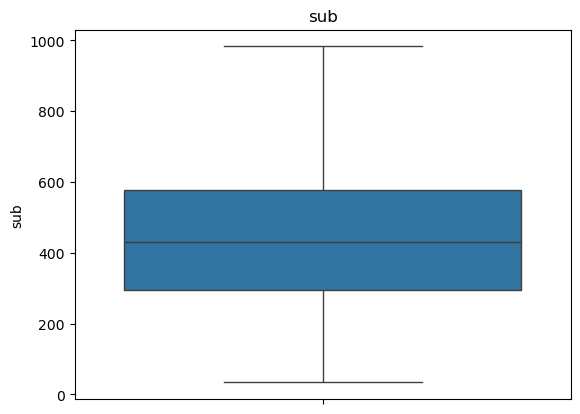

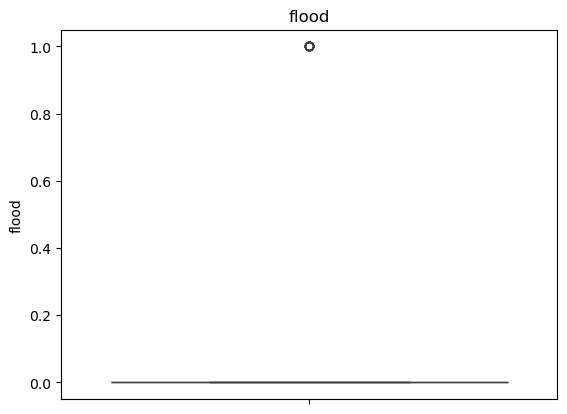

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in dataset.columns:
    sns.boxplot(dataset[col])
    plt.title(col)
    plt.show()

In [23]:
dataset.dtypes


Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

In [30]:
# Independent variables
X = dataset.drop("flood", axis=1)

# Dependent variable
y = dataset["flood"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (115, 10)
y shape: (115,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 86
Testing samples: 29


In [32]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [33]:
from joblib import dump
dump(sc, "transform.save")

['transform.save']

In [34]:
from sklearn import tree
from sklearn import ensemble
from sklearn import neighbors
import xgboost

# initialize models
dtree = tree.DecisionTreeClassifier()
Rf = ensemble.RandomForestClassifier()
knn = neighbors.KNeighborsClassifier()
xgb = xgboost.XGBClassifier()

# train models
dtree.fit(X_train, y_train)
Rf.fit(X_train, y_train)
knn.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [36]:
from sklearn import metrics

p1 = dtree.predict(X_test)
p2 = Rf.predict(X_test)
p3 = knn.predict(X_test)
p4 = xgb.predict(X_test)

print(metrics.accuracy_score(y_test,p1))
print(metrics.accuracy_score(y_test,p2))
print(metrics.accuracy_score(y_test,p3))
print(metrics.accuracy_score(y_test,p4))

1.0
1.0
0.896551724137931
1.0


In [37]:
from sklearn import metrics

# Confusion Matrix
print(metrics.confusion_matrix(y_test, p4))

# Accuracy
print(metrics.accuracy_score(y_test, p4))

# Precision
print(metrics.precision_score(y_test, p4))

# Recall
print(metrics.recall_score(y_test, p4))

[[23  0]
 [ 0  6]]
1.0
1.0
1.0


In [39]:
from joblib import dump

# save trained best model
dump(xgb, "floods.save")

# save scaler
dump(sc, "transform.save")

print("Model + Scaler saved successfully")

Model + Scaler saved successfully


In [40]:
print(dataset.columns)

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')


In [41]:
dataset.groupby("flood").mean()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub
flood,,,,,,,,,,
0,29.636364,73.828283,36.131313,2819.573737,28.494949,378.318182,1913.814141,498.928283,208.592929,410.335354
1,29.375000,74.000000,37.250000,3580.831250,23.062500,370.668750,2697.443750,489.643750,276.931250,622.125000


In [42]:
print(xgb.feature_importances_)

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
